In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

n_clusters = 5

def apply_pca(df, n_components=None):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)
    pca = PCA(n_components=n_components)
    transformed_data = pca.fit_transform(scaled_data)
    transformed_df = pd.DataFrame(transformed_data, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])
    return transformed_df, pca

df2=pd.read_excel(r'C:\Users\Philippe.ISOPE\Desktop\Theo Data Files\Boutons_variables\GluSnFR_avg_variables_allCa_filtered_3sigma.xlsx', sheet_name=1)
new_df2=df2.drop(['ID','Target'], axis=1) 
labels = new_df2.columns
transformed_df, pca = apply_pca(new_df2, n_components=2)
print(" explained variance: ", pca.explained_variance_ratio_)

 explained variance:  [0.43835616 0.34665829]


C:\Users\Philippe.ISOPE\anaconda3\envs\jupyterlab4\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


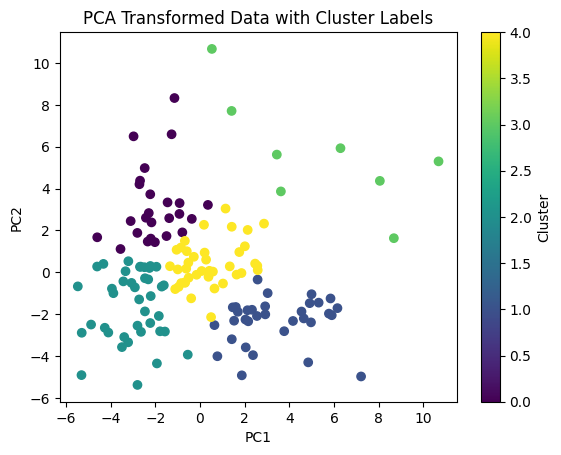

In [7]:
kmeans = KMeans(n_clusters=n_clusters, n_init= 'auto')
kmeans.fit(transformed_df)
cluster_labels = kmeans.labels_
transformed_df['Cluster'] = cluster_labels

plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data with Cluster Labels')
plt.colorbar(label='Cluster')
plt.show
plt.savefig('PCA.pdf')

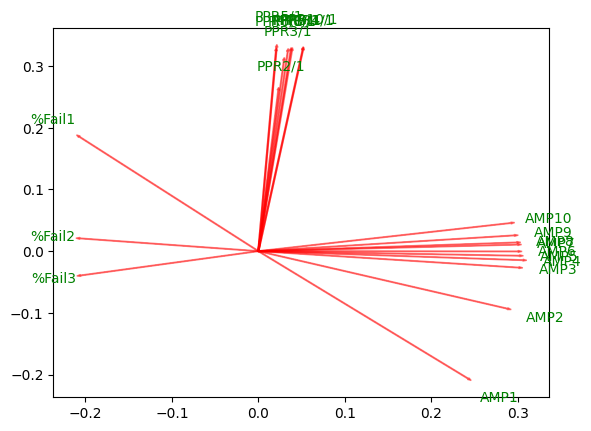

In [8]:
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]
for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
plt.savefig('PCA components.pdf')